# Smart-Traffic-Signal-Optimization-using-Reinforcement-Learning

In [1]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
# setting states and actions
states=['Low','Medium','High']
actions=['Green_NS','Green_EW']
# creating qtable
Q=np.zeros((3,2))
# setting hyper parameters
alpha=0.1
gamma=0.9
epsilon=0.2
episodes=100

In [2]:
def get_reward(traffic,action):
    if traffic=="High" and action=="Green_NS":
        return 10
    elif traffic=="Low" and action=="Green_EW":
        return 8
    else:
        return -5

In [3]:
for episode in range(episodes):
    state_index=random.randint(0,2)
    traffic=states[state_index]
    if random.uniform(0,1)<epsilon:
        action_index=random.randint(0,1)
    else:
        action_index=np.argmax(Q[state_index])
    reward=get_reward(traffic,actions[action_index])
    old_value=Q[state_index,action_index]
    next_max=np.max(Q[state_index])
    new_value=old_value+alpha*(reward+gamma*next_max-old_value)
    Q[state_index,action_index]=new_value
print("Trained Q-Table")
print(Q)

Trained Q-Table
[[ 2.27032541 16.51085731]
 [-7.61326895 -7.42711145]
 [31.7445405  -0.14536409]]


In [4]:
print("Traffic signal simulation")
for i in range(5):
    state_index=random.randint(0,2)
    traffic=states[state_index]
    best_action=np.argmax(Q[state_index])
    print("Traffic Density:",traffic)
    if actions[best_action]=="Green_NS":
        print("Signal:North-South GREEN")
    else:
        print("Signal:East-West GREEN")
    time.sleep(3)

Traffic signal simulation
Traffic Density: High
Signal:North-South GREEN
Traffic Density: Low
Signal:East-West GREEN
Traffic Density: Low
Signal:East-West GREEN
Traffic Density: Low
Signal:East-West GREEN
Traffic Density: Medium
Signal:East-West GREEN


[]

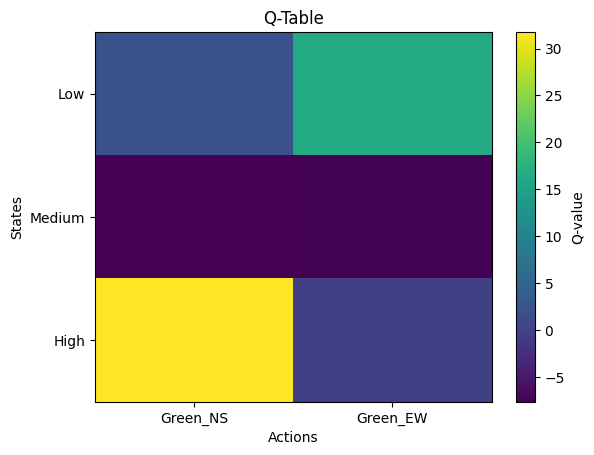

In [6]:
plt.imshow(Q, cmap='viridis', aspect='auto')
plt.colorbar(label='Q-value')
plt.xticks(range(len(actions)), actions)
plt.yticks(range(len(states)), states)
plt.xlabel('Actions')
plt.ylabel('States')
plt.title('Q-Table')
plt.plot()